# Attention as Manifold Learning

This notebook explores using self-attention mechanisms for manifold learning and dimensionality reduction. We compare attention-based embeddings with traditional manifold learning methods from scikit-learn.

## Hypothesis
The attention matrix learned through self-reconstruction can be interpreted as a similarity/distance matrix that captures the intrinsic manifold structure of the data, similar to what manifold learning algorithms discover.


In [53]:
# Import required libraries
import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn import datasets, manifold
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device detection
def get_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"Using CUDA device: {torch.cuda.get_device_name(0)}")
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print("Using MPS (Metal Performance Shaders) device")
    else:
        device = torch.device('cpu')
        print("Using CPU device")
    return device

device = get_device()


Using MPS (Metal Performance Shaders) device


## Feed-Forward MLP and Simple Self-Attention Model for Manifold Learning


In [54]:
class FeedForwardMLP(nn.Module):
    """
    Two-layer feed-forward MLP with GELU activation and dropout.
    """
    def __init__(self, input_dim, output_dim, mlp_expansion=2, dropout=0.0):
        """
        Args:
            input_dim: input feature dimension
            output_dim: output feature dimension
            mlp_expansion: expansion factor for hidden layer
            dropout: dropout rate
        """
        super().__init__()
        hidden_dim = int(input_dim * mlp_expansion)
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        return self.net(x)

class SimpleSelfAttention(nn.Module):
    """
    Simple self-attention model for manifold learning.
    Learns attention weights through self-reconstruction.
    Supports both linear and MLP projections for Q/K.
    Supports attention dropout for regularization.
    """
    def __init__(self, d_model, n_hidden, use_attention_scores=False, use_mlp_projections=False):
        super().__init__()
        # Q, K projections - can use MLP for nonlinear transformations
        if use_mlp_projections:
            self.W_Q = FeedForwardMLP(d_model, n_hidden, mlp_expansion=2, dropout=0.0)
            self.W_K = FeedForwardMLP(d_model, n_hidden, mlp_expansion=2, dropout=0.0)
        else:
            self.W_Q = nn.Linear(d_model, n_hidden, bias=False)  # Query projection
            self.W_K = nn.Linear(d_model, n_hidden, bias=False)  # Key projection
        self.W_V = nn.Identity()  # Value projection (identity)
        self.d_model = d_model
        self.n_hidden = n_hidden
        self.use_attention_scores = use_attention_scores
        self.use_mlp_projections = use_mlp_projections
    
    def forward(self, x, attn_mask=None, attn_dropout=0.0):
        """
        Args:
            x: (batch, n_points, d_model) input points
            attn_mask: optional mask tensor of shape (batch, n_points, n_points)
            attn_dropout: float between 0 and 1, fraction of neurons to randomly mask per row
        Returns:
            Dictionary with output, attn_weights, attn_scores, attn_mask
        """
        batch_size, n_points, d_model = x.shape
        device = x.device
        
        # Compute Q, K, V
        Q = self.W_Q(x)  # (batch, n_points, n_hidden)
        K = self.W_K(x)  # (batch, n_points, n_hidden)
        V = self.W_V(x)  # (batch, n_points, d_model)
        
        # Create base diagonal mask (1 everywhere except diagonal)
        if attn_mask is None:
            attn_mask = (1 - torch.eye(n_points, device=device)).unsqueeze(0).expand(batch_size, -1, -1)
        
        # Apply attention dropout if specified
        if attn_dropout > 0:
            # Calculate number of neurons to mask per row
            n_mask = int(attn_dropout * n_points)
            if n_mask > 0:
                # Clone mask to avoid modifying the original
                attn_mask = attn_mask.clone()
                
                # Efficient vectorized approach: generate random column indices for each row
                # Shape: (batch_size, n_points, n_mask) - random columns to mask for each row
                random_col_indices = torch.randint(0, n_points, (batch_size, n_points, n_mask), device=device)
                
                # Create dropout mask and use scatter_ for efficient assignment
                dropout_mask = torch.zeros((batch_size, n_points, n_points), device=device)
                # scatter_ along dim=2 (column dimension) to set mask positions
                dropout_mask.scatter_(2, random_col_indices, 1)
                
                # Apply dropout mask to attention mask
                attn_mask = attn_mask * (1 - dropout_mask)
        
        # Compute attention scores
        scores = torch.bmm(Q, K.transpose(1, 2)) / (self.n_hidden**0.5)
        
        # Apply mask
        inf_masked_scores = scores.masked_fill(attn_mask == 0, float("-inf"))
        attn_weights = torch.softmax(inf_masked_scores, dim=-1)
        attn_scores = scores.masked_fill(attn_mask == 0, 0.0)
        
        # Reconstruct
        if self.use_attention_scores:
            reconstructed = torch.bmm(attn_scores, V)
        else:
            reconstructed = torch.bmm(attn_weights, V)
        
        return {
            'output': reconstructed,
            'attn_weights': attn_weights,
            'attn_scores': attn_scores,
            'attn_mask': attn_mask
        }


## Dataset Class for Manifold Learning


In [55]:
class ManifoldDataset(Dataset):
    """
    Dataset for manifold learning with optional windowing.
    Can return full data or windows of the data.
    """
    def __init__(self, X, num_samples=1000, seq_len=None, stride=1):
        """
        Args:
            X: (N_points, D) numpy array of data points
            num_samples: number of samples to generate
            seq_len: if None, return full data. If int, return windows of seq_len points
            stride: stride for sliding window (only used if seq_len is not None)
        """
        self.X = torch.tensor(X, dtype=torch.float32)
        self.N_points, self.D = self.X.shape
        self.seq_len = seq_len if seq_len is not None else self.N_points
        self.stride = stride
        self.num_samples = num_samples
        
        # If windowing, calculate number of possible windows
        if seq_len is not None and seq_len < self.N_points:
            # Number of windows that fit
            self.n_windows = max(1, (self.N_points - seq_len) // stride + 1)
            # If we need more samples than windows, we'll cycle through them
        else:
            # Full data mode
            self.n_windows = 1
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        if self.seq_len is None or self.seq_len >= self.N_points:
            # Return full data
            return self.X.clone()
        else:
            # Return a window
            window_idx = idx % self.n_windows
            start_idx = window_idx * self.stride
            end_idx = start_idx + self.seq_len
            
            # Handle edge case where window goes beyond data
            if end_idx > self.N_points:
                start_idx = self.N_points - self.seq_len
                end_idx = self.N_points
            
            return self.X[start_idx:end_idx].clone()


## Training Function


In [56]:
def train_attention_manifold(model, dataset, config, device):
    """
    Train attention model for manifold learning.
    
    Args:
        model: SimpleSelfAttention model
        dataset: ManifoldDataset
        config: Configuration dictionary with 'loss_type' ('l1' or 'mse'), 'attn_dropout', etc.
        device: torch device
    """
    # Select loss function based on config
    loss_type = config.get('loss_type', 'mse').lower()
    if loss_type == 'l1':
        criterion = nn.L1Loss()
    elif loss_type == 'mse':
        criterion = nn.MSELoss()
    else:
        raise ValueError(f"Unknown loss_type: {loss_type}. Must be 'l1' or 'mse'")
    
    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'])
    
    loader = DataLoader(dataset, batch_size=config['batch_size'], shuffle=True)
    
    history = {'losses': []}
    
    # Get attention dropout from config
    attn_dropout = config.get('attn_dropout', 0.0)
    
    for epoch in range(config['num_epochs']):
        epoch_losses = []
        for batch in loader:
            batch = batch.to(device)
            
            # Forward pass with attention dropout
            out = model(batch, attn_dropout=attn_dropout)
            recon = out['output']
            
            # Reconstruction loss
            loss = criterion(recon, batch)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_losses.append(loss.item())
        
        avg_loss = np.mean(epoch_losses)
        history['losses'].append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{config['num_epochs']}, Loss: {avg_loss:.6f}")
    
    return history


## Extract Attention-Based Embeddings

We'll use the attention matrix as a similarity matrix and convert it to distances for MDS, following the approach from the main notebook.


In [57]:
def extract_attention_embedding(model, X, device, use_attention_scores=False, n_samples=100, attn_dropout=0.0):
    """
    Extract attention matrix and convert to 2D embedding using MDS.
    
    Args:
        model: Trained SimpleSelfAttention model
        X: (N_points, D) numpy array of data points
        device: torch device
        use_attention_scores: If True, use raw scores instead of weights
        n_samples: Number of forward passes to average over
        attn_dropout: Attention dropout rate (0.0 for deterministic extraction)
    
    Returns:
        embedding: (N_points, 2) numpy array of 2D coordinates
        attention_matrix: (N_points, N_points) averaged attention matrix
    """
    model.eval()
    attention_matrices = []
    
    X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(0).to(device)  # Add batch dim
    
    with torch.no_grad():
        for _ in range(n_samples):
            out = model(X_tensor, attn_dropout=attn_dropout)
            if use_attention_scores:
                attn = out['attn_scores'].cpu().numpy()[0]  # Remove batch dim
            else:
                attn = out['attn_weights'].cpu().numpy()[0]
            attention_matrices.append(attn)
    
    # Average attention matrices
    attention_matrix = np.mean(attention_matrices, axis=0)
    
    # Convert attention (similarity) to distance matrix
    # Restore diagonal to 1.0 (self-similarity)
    np.fill_diagonal(attention_matrix, 1.0)
    
    # Symmetrize
    attention_similarity = np.clip(0.5 * (attention_matrix + attention_matrix.T), 0, 1)
    
    # Convert similarity to distance using information distance (same as main notebook)
    eps = 1e-9
    attention_distance = np.sqrt(np.maximum(0.0, -np.log(attention_similarity + eps)))
    
    # Apply MDS to get 2D embedding
    mds = manifold.MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress=False)
    embedding = mds.fit_transform(attention_distance)
    
    return embedding, attention_matrix


## Generate Datasets

We'll use the same datasets as sklearn's manifold learning examples (see [sklearn documentation](https://scikit-learn.org/stable/auto_examples/manifold/plot_compare_methods.html)).


In [58]:
# Generate S-curve dataset
n_samples = 1500
S_points_full, S_color_full = datasets.make_s_curve(n_samples, random_state=0)

# Split into train/test (50/50)
from sklearn.model_selection import train_test_split
S_points_train, S_points_test, S_color_train, S_color_test = train_test_split(
    S_points_full, S_color_full, test_size=0.5, random_state=42
)

print(f"S-curve dataset: {S_points_full.shape}")
print(f"Train set: {S_points_train.shape}, Test set: {S_points_test.shape}")
print(f"Color range: [{S_color_full.min():.2f}, {S_color_full.max():.2f}]")


S-curve dataset: (1500, 3)
Train set: (750, 3), Test set: (750, 3)
Color range: [-4.71, 4.71]


## Visualization Functions


In [59]:
# Import for 3D plotting
import mpl_toolkits.mplot3d  # noqa: F401

def plot_3d(points, color, title, ax=None):
    """Plot 3D data."""
    if ax is None:
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')
    x, y, z = points.T
    ax.scatter(x, y, z, c=color, s=50, alpha=0.8, cmap=plt.cm.Spectral)
    ax.set_title(title, size=14, fontweight='bold')
    return ax

def plot_2d(points, color, title, ax=None):
    """Plot 2D embedding."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(points[:, 0], points[:, 1], c=color, s=50, alpha=0.8, cmap=plt.cm.Spectral)
    ax.set_title(title, size=14, fontweight='bold')
    ax.set_aspect('equal')
    return ax


## Train Attention Model on S-Curve


In [60]:
# Configuration
CONFIG = {
    'd_model': 3,  # S-curve is 3D
    'n_hidden': 64,
    'batch_size': 32,
    'learning_rate': 1e-3,
    'num_epochs': 100,
    'use_attention_scores': False,
    'use_mlp_projections': False,  # Will test both linear and MLP
    'seq_len': None,  # None = full data, or int for windowing
    'stride': 1,  # Only used if seq_len is not None
    'loss_type': 'mse',  # 'mse' or 'l1' for reconstruction loss
    'attn_dropout': 0.05  # Dropout for attention mask beyond diagonal (self) masking
}

# Create train dataset (using train split)
dataset = ManifoldDataset(
    S_points_train, 
    num_samples=1000,
    seq_len=CONFIG.get('seq_len', None),
    stride=CONFIG.get('stride', 1)
)

print(f"Train dataset created: {len(dataset)} samples")
if CONFIG.get('seq_len') is not None:
    print(f"  Window size: {CONFIG['seq_len']}, Stride: {CONFIG['stride']}")
else:
    print(f"  Using full data: {S_points_train.shape[0]} points")


Train dataset created: 1000 samples
  Using full data: 750 points


## Compare with Traditional Manifold Learning Methods

We'll apply various manifold learning methods from scikit-learn and compare them with our attention-based approach.


In [61]:
# Apply various manifold learning methods
# IMPORTANT: Fit on train, transform test
n_neighbors = 12
n_components = 2

methods = {}

# PCA (baseline linear method) - fit on train, transform test
pca = PCA(n_components=n_components, random_state=42)
pca.fit(S_points_train)
methods['PCA'] = pca.transform(S_points_test)

# Locally Linear Embedding (LLE) - fit on train, transform test
lle = manifold.LocallyLinearEmbedding(
    n_neighbors=n_neighbors, 
    n_components=n_components, 
    random_state=42
)
lle.fit(S_points_train)
methods['LLE'] = lle.transform(S_points_test)

# Isomap - fit on train, transform test
isomap = manifold.Isomap(n_neighbors=n_neighbors, n_components=n_components)
isomap.fit(S_points_train)
methods['Isomap'] = isomap.transform(S_points_test)

# MDS - doesn't have transform, use fit_transform on train
# Note: MDS doesn't support out-of-sample extension
mds = manifold.MDS(n_components=n_components, random_state=42, normalized_stress=False)
mds_train = mds.fit_transform(S_points_train)
methods['MDS'] = mds_train  # Using train embedding (MDS limitation)

# Spectral Embedding - doesn't have transform, use fit_transform on train
# Note: SpectralEmbedding doesn't support out-of-sample extension
spectral = manifold.SpectralEmbedding(
    n_components=n_components, 
    n_neighbors=n_neighbors, 
    random_state=42
)
spectral_train = spectral.fit_transform(S_points_train)
methods['Spectral'] = spectral_train  # Using train embedding (SpectralEmbedding limitation)

# t-SNE - fit on train, transform test
tsne = manifold.TSNE(
    n_components=n_components,
    perplexity=30,
    random_state=42,
    init='random'
)
# Note: t-SNE doesn't have transform, so we fit on train and use train embedding
# For fair comparison, we'll fit on train and show train embedding
tsne_train = tsne.fit_transform(S_points_train)
# For visualization, we'll use train embedding but note this in the plot
methods['t-SNE'] = tsne_train  # Using train embedding (t-SNE limitation)

# Note: Attention-based methods (Linear and MLP) will be added after training in the next section
# They will also be evaluated on test set

print(f"Applied {len(methods)} sklearn methods (fitted on train, transformed test):")
for name, embedding in methods.items():
    print(f"  {name}: {embedding.shape}")
print("\n(Attention methods will be added after training in the next section)")


Applied 6 sklearn methods (fitted on train, transformed test):
  PCA: (750, 2)
  LLE: (750, 2)
  Isomap: (750, 2)
  MDS: (750, 2)
  Spectral: (750, 2)
  t-SNE: (750, 2)

(Attention methods will be added after training in the next section)


## Compare Linear vs MLP Projections

Let's test both linear and nonlinear (MLP) projections to see if MLP better approximates nonlinear manifold learning methods.


In [62]:
# Test both linear and MLP projections
print("="*80)
print("Testing Linear vs MLP Projections")
print("="*80)

# Linear projections
print("\n1. Training with LINEAR projections...")
CONFIG_LINEAR = CONFIG.copy()
CONFIG_LINEAR['use_mlp_projections'] = False

model_linear = SimpleSelfAttention(
    d_model=CONFIG_LINEAR['d_model'],
    n_hidden=CONFIG_LINEAR['n_hidden'],
    use_attention_scores=CONFIG_LINEAR['use_attention_scores'],
    use_mlp_projections=CONFIG_LINEAR['use_mlp_projections']
).to(device)

print(f"Linear model parameters: {sum(p.numel() for p in model_linear.parameters()):,}")
history_linear = train_attention_manifold(model_linear, dataset, CONFIG_LINEAR, device)
# Extract embedding on TEST set
embedding_linear, _ = extract_attention_embedding(
    model_linear, S_points_test, device, 
    use_attention_scores=CONFIG_LINEAR['use_attention_scores'],
    n_samples=100
)

# MLP projections
print("\n2. Training with MLP (nonlinear) projections...")
CONFIG_MLP = CONFIG.copy()
CONFIG_MLP['use_mlp_projections'] = True

model_mlp = SimpleSelfAttention(
    d_model=CONFIG_MLP['d_model'],
    n_hidden=CONFIG_MLP['n_hidden'],
    use_attention_scores=CONFIG_MLP['use_attention_scores'],
    use_mlp_projections=CONFIG_MLP['use_mlp_projections']
).to(device)

print(f"MLP model parameters: {sum(p.numel() for p in model_mlp.parameters()):,}")
history_mlp = train_attention_manifold(model_mlp, dataset, CONFIG_MLP, device)
# Extract embedding on TEST set
embedding_mlp, _ = extract_attention_embedding(
    model_mlp, S_points_test, device,
    use_attention_scores=CONFIG_MLP['use_attention_scores'],
    n_samples=100
)

# Add to methods dictionary
methods['Attention (Linear)'] = embedding_linear
methods['Attention (MLP)'] = embedding_mlp

print(f"\nSummary:")
print(f"  Linear model parameters: {sum(p.numel() for p in model_linear.parameters()):,}")
print(f"  MLP model parameters: {sum(p.numel() for p in model_mlp.parameters()):,}")
print(f"  Total methods for comparison: {len(methods)}")


Testing Linear vs MLP Projections

1. Training with LINEAR projections...
Linear model parameters: 384
Epoch 10/100, Loss: 0.154450
Epoch 20/100, Loss: 0.114589
Epoch 30/100, Loss: 0.106623
Epoch 40/100, Loss: 0.104009
Epoch 50/100, Loss: 0.102889
Epoch 60/100, Loss: 0.102320
Epoch 70/100, Loss: 0.102005
Epoch 80/100, Loss: 0.101824
Epoch 90/100, Loss: 0.101715
Epoch 100/100, Loss: 0.101649

2. Training with MLP (nonlinear) projections...
MLP model parameters: 944
Epoch 10/100, Loss: 0.244138
Epoch 20/100, Loss: 0.116621
Epoch 30/100, Loss: 0.025192
Epoch 40/100, Loss: 0.021252
Epoch 50/100, Loss: 0.019504
Epoch 60/100, Loss: 0.018053
Epoch 70/100, Loss: 0.016751
Epoch 80/100, Loss: 0.015451
Epoch 90/100, Loss: 0.014034
Epoch 100/100, Loss: 0.013070

Summary:
  Linear model parameters: 384
  MLP model parameters: 944
  Total methods for comparison: 8


## Visualize Comparisons


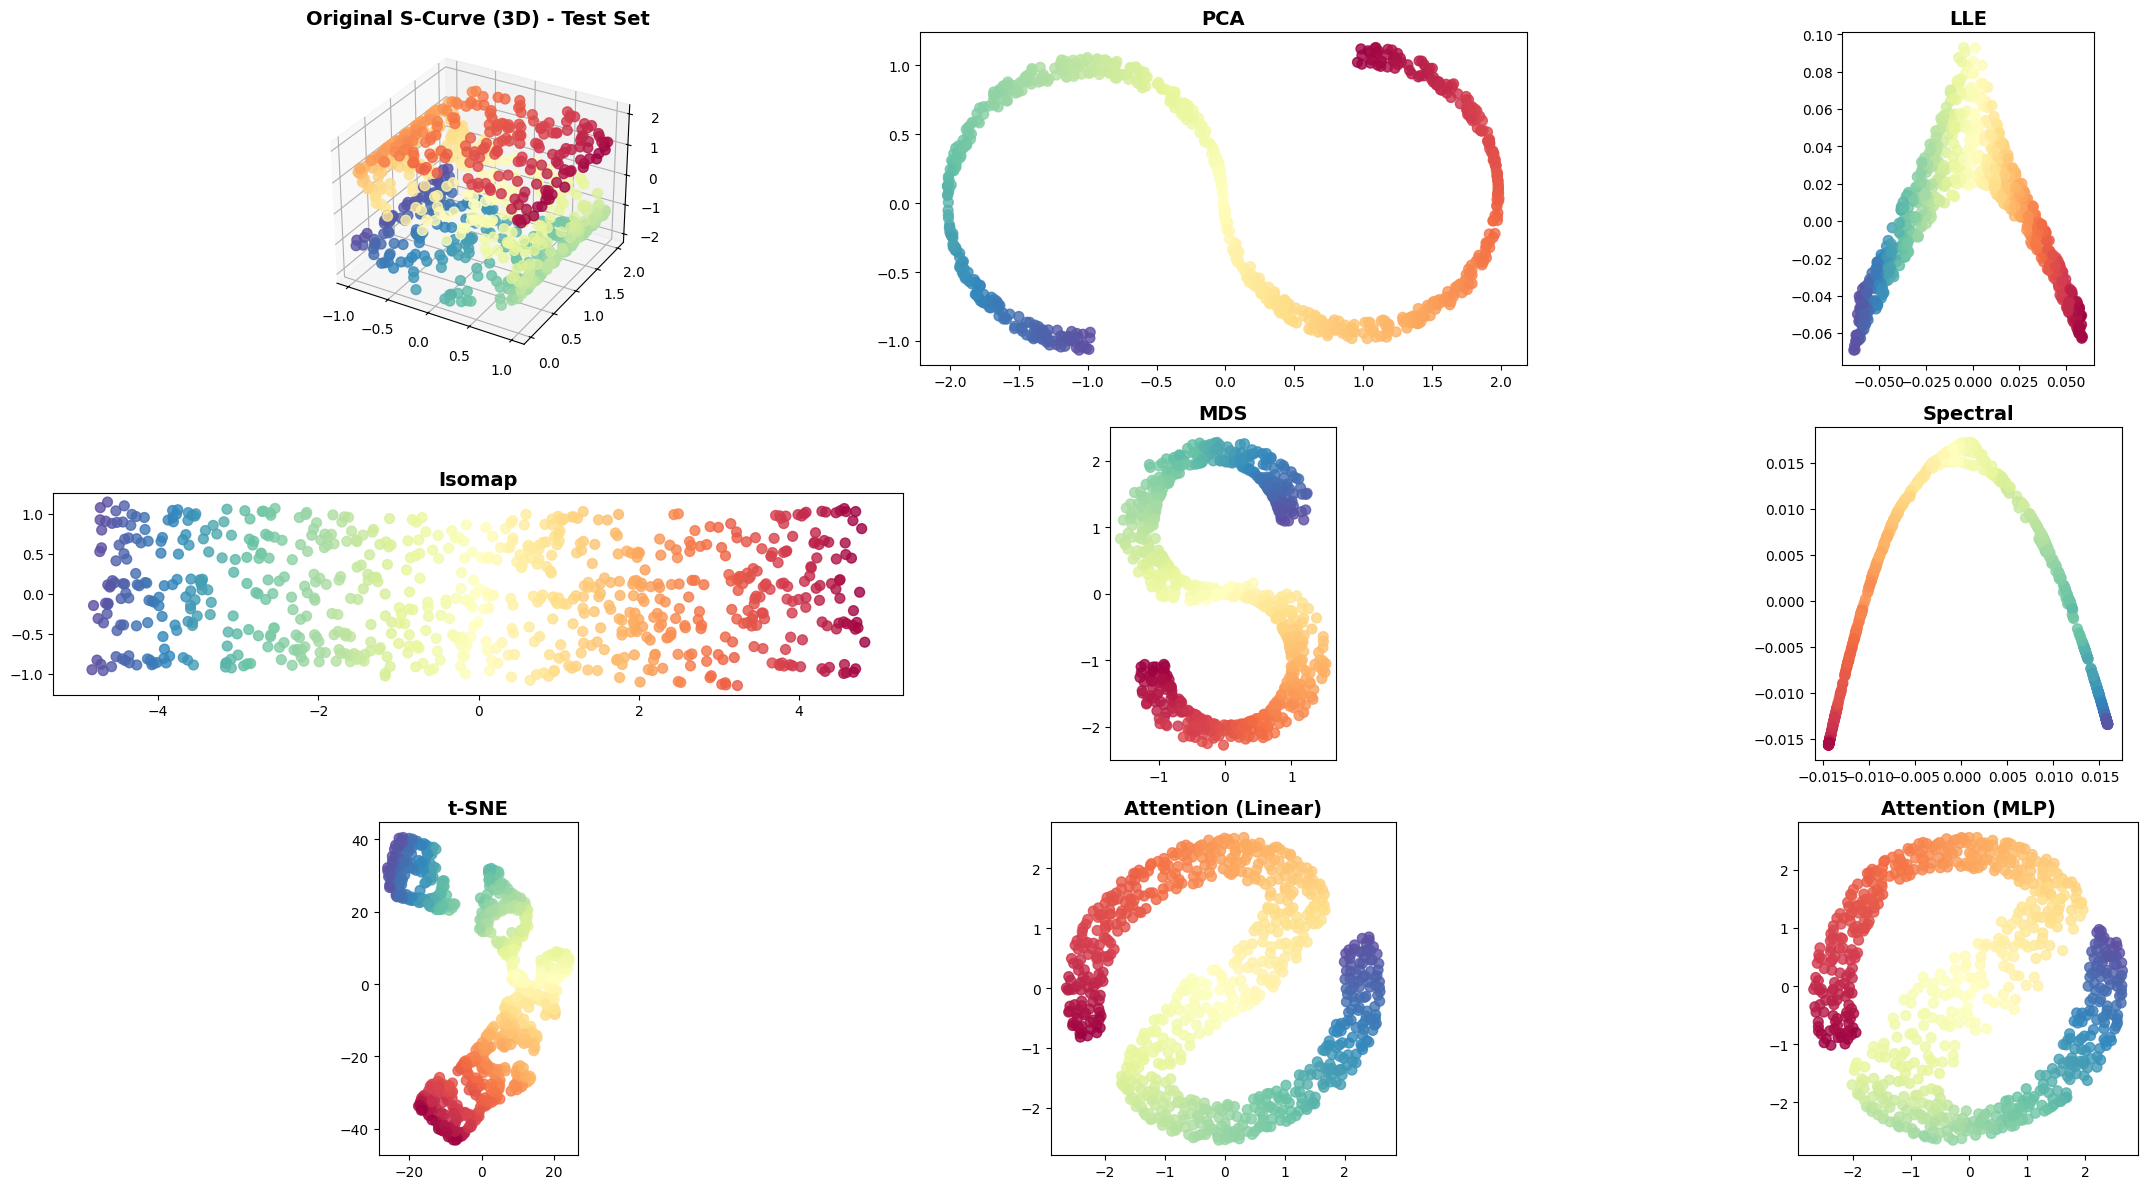

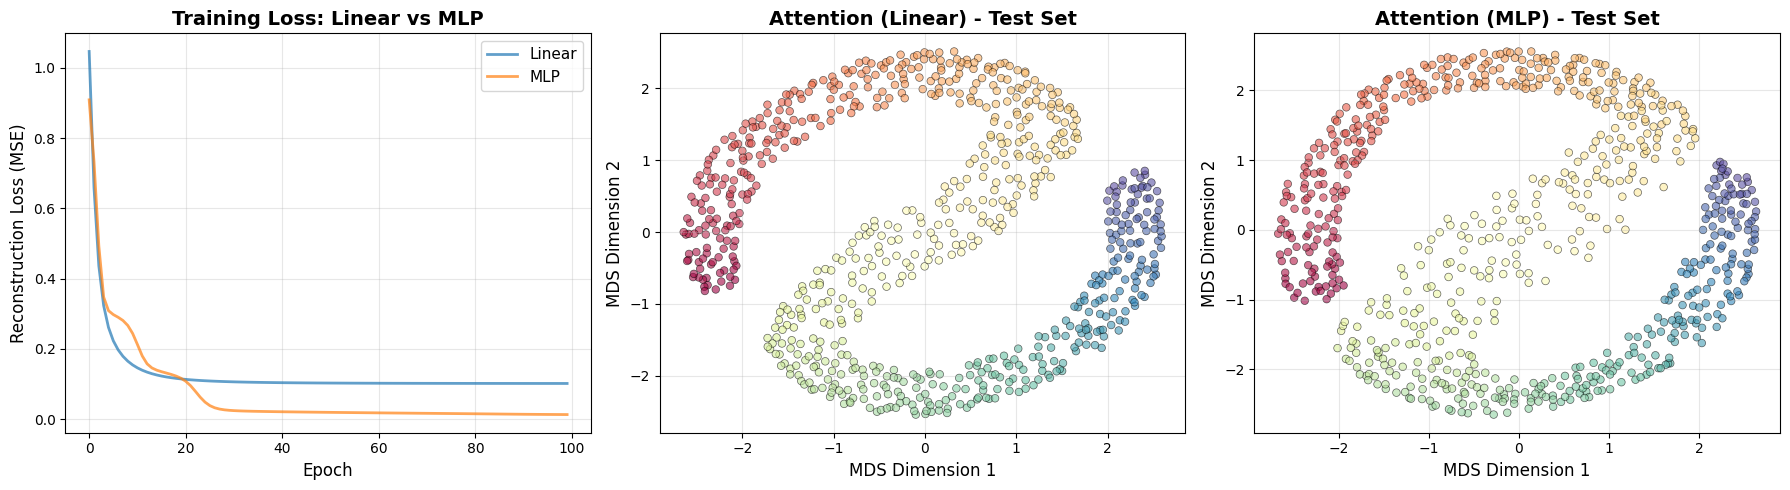

In [65]:
# Create comparison plot (including both linear and MLP attention on separate subplots)
# Methods that use test set: PCA, LLE, Isomap, Attention (Linear), Attention (MLP)
# Methods that use train set: MDS, Spectral, t-SNE (limitation - no transform method)
fig = plt.figure(figsize=(24, 12))

# Plot original 3D data (TEST set)
ax = fig.add_subplot(3, 3, 1, projection='3d')
plot_3d(S_points_test, S_color_test, 'Original S-Curve (3D) - Test Set', ax)

# Plot sklearn methods - use appropriate color array based on train/test
sklearn_methods = ['PCA', 'LLE', 'Isomap', 'MDS', 'Spectral', 't-SNE']
train_set_methods = ['MDS', 'Spectral', 't-SNE']  # These use train embeddings

for idx, method_name in enumerate(sklearn_methods, start=2):
    if method_name in methods:
        ax = fig.add_subplot(3, 3, idx)
        # Use train colors for methods that use train embeddings, test colors otherwise
        color_array = S_color_train if method_name in train_set_methods else S_color_test
        plot_2d(methods[method_name], color_array, method_name, ax)

# Plot attention methods on separate subplots (both use test set)
ax = fig.add_subplot(3, 3, 8)
plot_2d(methods['Attention (Linear)'], S_color_test, 'Attention (Linear)', ax)

ax = fig.add_subplot(3, 3, 9)
plot_2d(methods['Attention (MLP)'], S_color_test, 'Attention (MLP)', ax)

plt.tight_layout()
plt.show()

# Plot training curves and embeddings in the same figure (3 columns)
plt.figure(figsize=(18, 5))

# Left panel: Training curves
plt.subplot(1, 3, 1)
plt.plot(history_linear['losses'], label='Linear', alpha=0.7, linewidth=2)
plt.plot(history_mlp['losses'], label='MLP', alpha=0.7, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Reconstruction Loss (MSE)', fontsize=12)
plt.title('Training Loss: Linear vs MLP', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Middle panel: Attention (Linear) embedding - TEST set
plt.subplot(1, 3, 2)
plt.scatter(embedding_linear[:, 0], embedding_linear[:, 1], c=S_color_test, s=30, alpha=0.6, cmap=plt.cm.Spectral, edgecolors='black', linewidths=0.5)
plt.xlabel('MDS Dimension 1', fontsize=12)
plt.ylabel('MDS Dimension 2', fontsize=12)
plt.title('Attention (Linear) - Test Set', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Right panel: Attention (MLP) embedding - TEST set
plt.subplot(1, 3, 3)
plt.scatter(embedding_mlp[:, 0], embedding_mlp[:, 1], c=S_color_test, s=30, alpha=0.6, cmap=plt.cm.Spectral, edgecolors='black', linewidths=0.5)
plt.xlabel('MDS Dimension 1', fontsize=12)
plt.ylabel('MDS Dimension 2', fontsize=12)
plt.title('Attention (MLP) - Test Set', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Compare Linear vs MLP Projections

Let's test both linear and nonlinear (MLP) projections to see if MLP better approximates nonlinear manifold learning methods.


## Test on Swiss Roll Dataset

Let's test on another classic manifold learning dataset.


Swiss Roll dataset: (1500, 3)
Train set: (750, 3), Test set: (750, 3)

Swiss Roll: Testing Linear vs MLP Projections

Training Swiss Roll with LINEAR projections...
Epoch 10/100, Loss: 10.651002
Epoch 20/100, Loss: 10.632499
Epoch 30/100, Loss: 10.632757
Epoch 40/100, Loss: 10.632527
Epoch 50/100, Loss: 10.632361
Epoch 60/100, Loss: 10.633022
Epoch 70/100, Loss: 10.632927
Epoch 80/100, Loss: 10.633346
Epoch 90/100, Loss: 10.633854
Epoch 100/100, Loss: 10.633940

Training Swiss Roll with MLP projections...
Epoch 10/100, Loss: 4.093266
Epoch 20/100, Loss: 1.286218
Epoch 30/100, Loss: 0.870346
Epoch 40/100, Loss: 0.744048
Epoch 50/100, Loss: 0.679098
Epoch 60/100, Loss: 0.634919
Epoch 70/100, Loss: 0.595464
Epoch 80/100, Loss: 0.550183
Epoch 90/100, Loss: 0.515485
Epoch 100/100, Loss: 0.495725


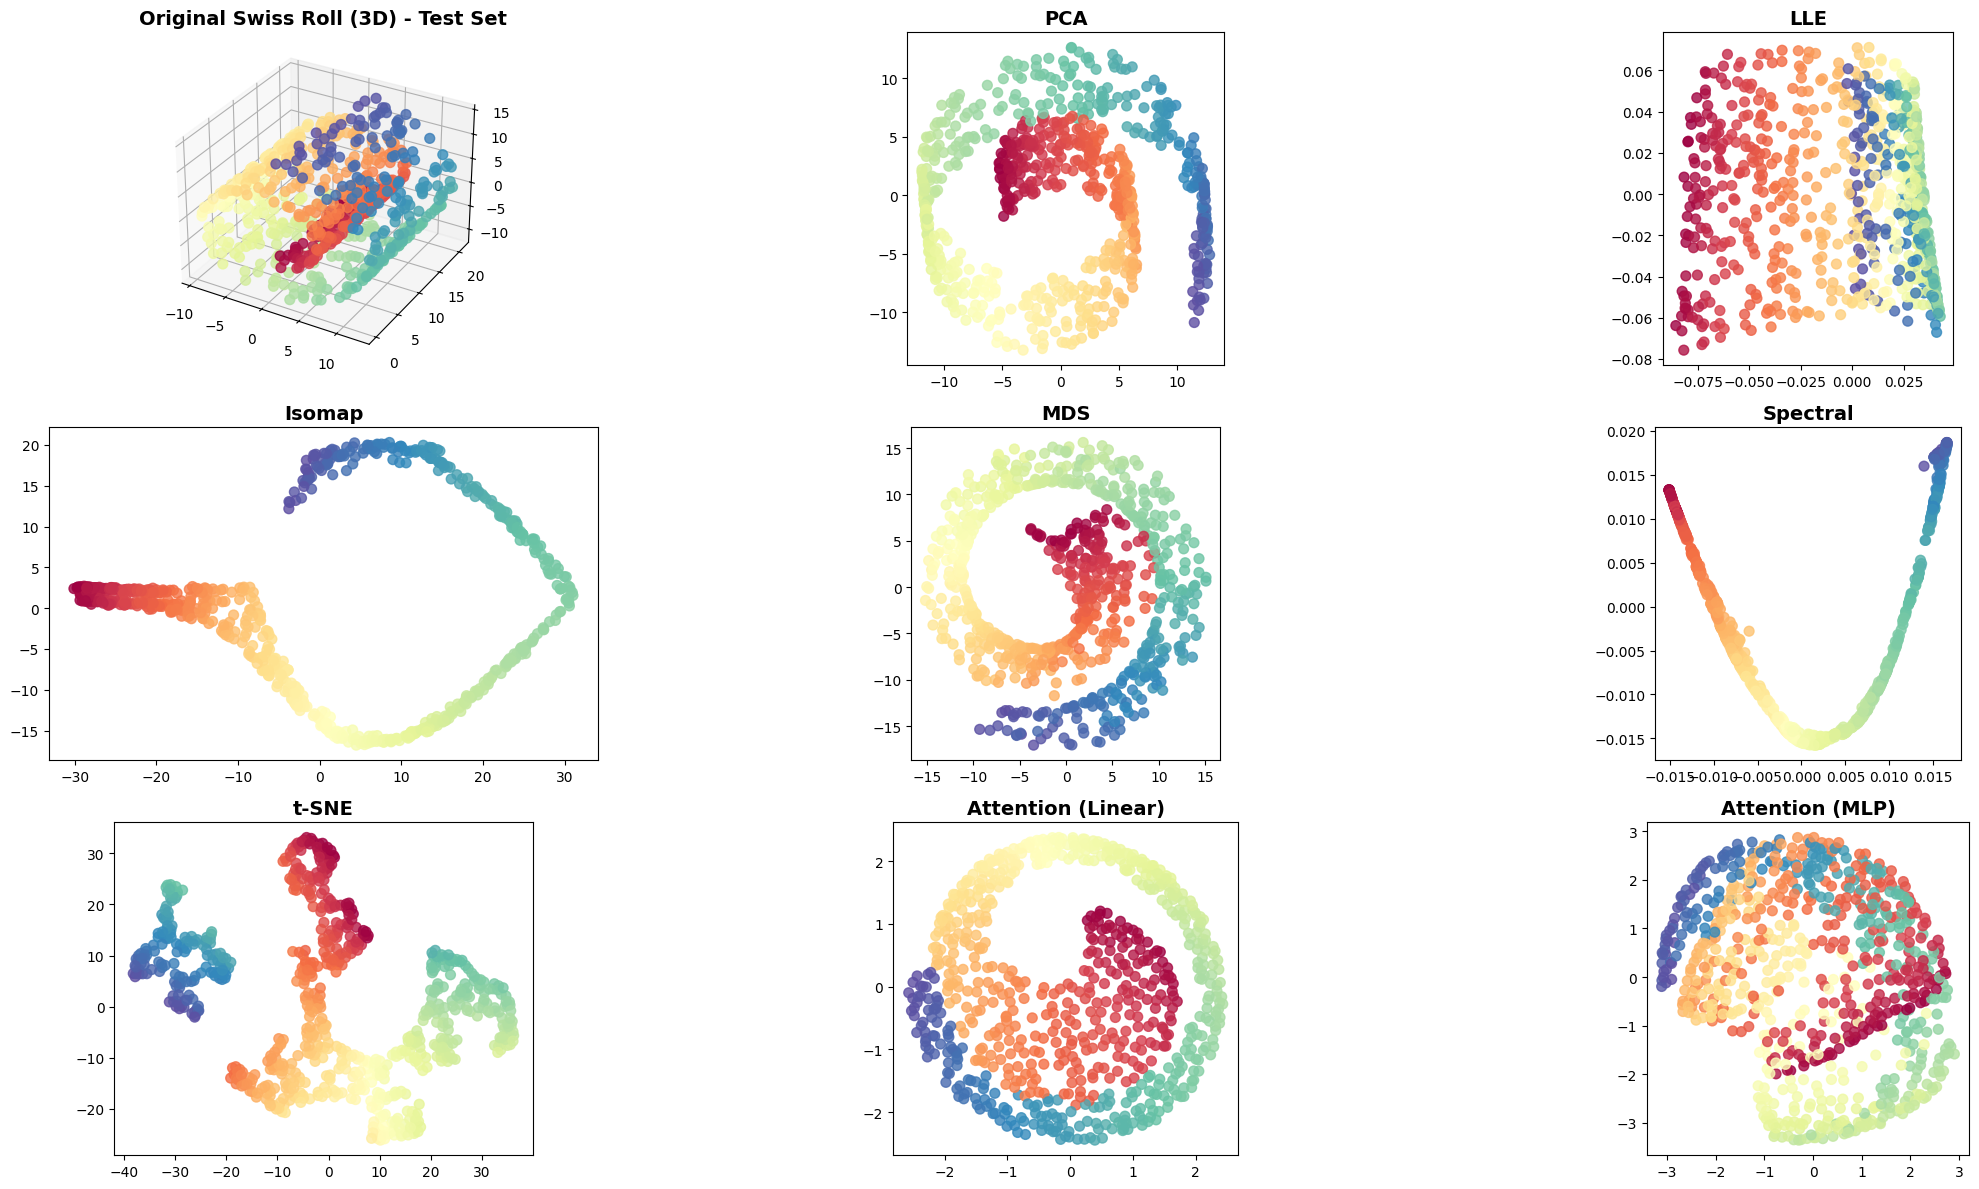

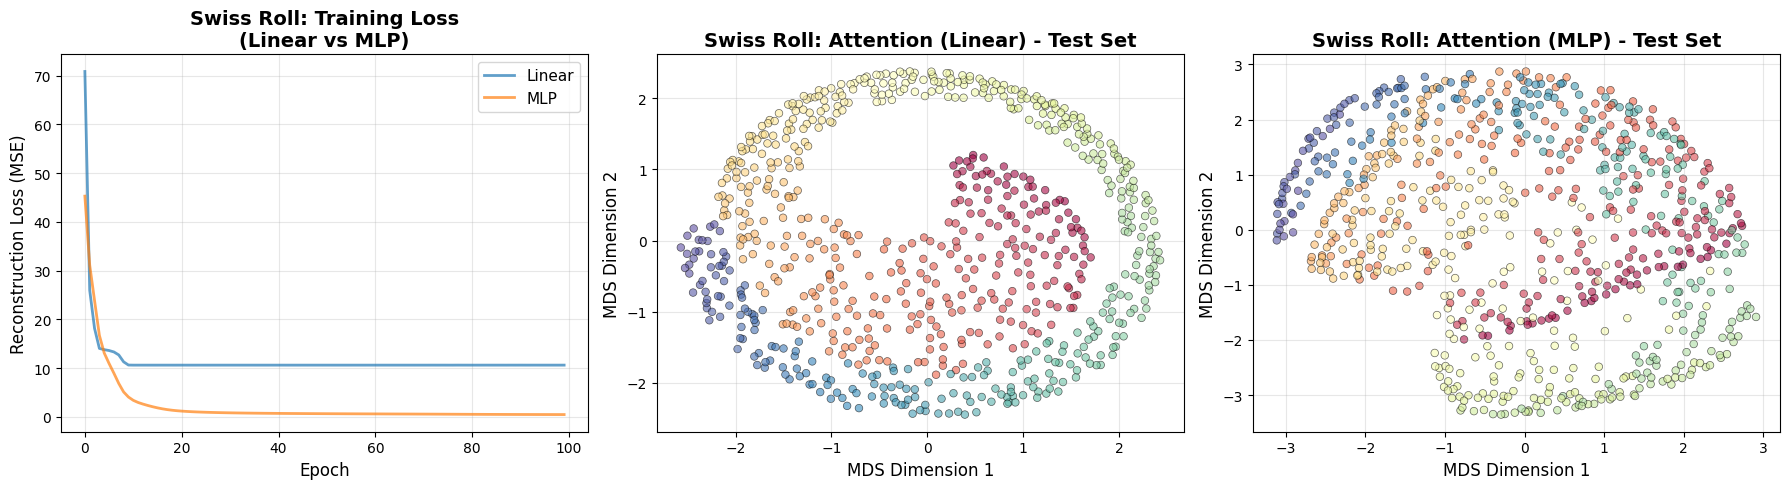

In [66]:
# Generate Swiss Roll dataset
swiss_points_full, swiss_color_full = datasets.make_swiss_roll(n_samples=1500, random_state=42)

# Split into train/test (50/50)
swiss_points_train, swiss_points_test, swiss_color_train, swiss_color_test = train_test_split(
    swiss_points_full, swiss_color_full, test_size=0.5, random_state=42
)

print(f"Swiss Roll dataset: {swiss_points_full.shape}")
print(f"Train set: {swiss_points_train.shape}, Test set: {swiss_points_test.shape}")

# Train on Swiss Roll with both linear and MLP
print("\n" + "="*80)
print("Swiss Roll: Testing Linear vs MLP Projections")
print("="*80)

swiss_dataset = ManifoldDataset(
    swiss_points_train, 
    num_samples=1000,
    seq_len=CONFIG.get('seq_len', None),
    stride=CONFIG.get('stride', 1)
)

# Linear
swiss_model_linear = SimpleSelfAttention(
    d_model=3,
    n_hidden=64,
    use_attention_scores=CONFIG['use_attention_scores'],
    use_mlp_projections=False
).to(device)

print("\nTraining Swiss Roll with LINEAR projections...")
swiss_history_linear = train_attention_manifold(swiss_model_linear, swiss_dataset, CONFIG, device)
# Extract embedding on TEST set
swiss_embedding_linear, _ = extract_attention_embedding(
    swiss_model_linear, swiss_points_test, device, n_samples=100
)

# MLP
swiss_model_mlp = SimpleSelfAttention(
    d_model=3,
    n_hidden=64,
    use_attention_scores=CONFIG['use_attention_scores'],
    use_mlp_projections=True
).to(device)

print("\nTraining Swiss Roll with MLP projections...")
swiss_history_mlp = train_attention_manifold(swiss_model_mlp, swiss_dataset, CONFIG, device)
# Extract embedding on TEST set
swiss_embedding_mlp, _ = extract_attention_embedding(
    swiss_model_mlp, swiss_points_test, device, n_samples=100
)

# Apply other methods - fit on train, transform test
swiss_methods = {}
pca_swiss = PCA(n_components=2, random_state=42)
pca_swiss.fit(swiss_points_train)
swiss_methods['PCA'] = pca_swiss.transform(swiss_points_test)

lle_swiss = manifold.LocallyLinearEmbedding(n_neighbors=12, n_components=2, random_state=42)
lle_swiss.fit(swiss_points_train)
swiss_methods['LLE'] = lle_swiss.transform(swiss_points_test)

isomap_swiss = manifold.Isomap(n_neighbors=12, n_components=2)
isomap_swiss.fit(swiss_points_train)
swiss_methods['Isomap'] = isomap_swiss.transform(swiss_points_test)

# MDS - doesn't have transform, use fit_transform on train
mds_swiss = manifold.MDS(n_components=2, random_state=42, normalized_stress=False)
swiss_methods['MDS'] = mds_swiss.fit_transform(swiss_points_train)  # Using train (MDS limitation)

# Spectral Embedding - doesn't have transform, use fit_transform on train
spectral_swiss = manifold.SpectralEmbedding(n_components=2, n_neighbors=12, random_state=42)
swiss_methods['Spectral'] = spectral_swiss.fit_transform(swiss_points_train)  # Using train (SpectralEmbedding limitation)

# t-SNE doesn't have transform, use train embedding
tsne_swiss = manifold.TSNE(n_components=2, perplexity=30, random_state=42, init='random')
swiss_methods['t-SNE'] = tsne_swiss.fit_transform(swiss_points_train)  # Using train (t-SNE limitation)
swiss_methods['Attention (Linear)'] = swiss_embedding_linear
swiss_methods['Attention (MLP)'] = swiss_embedding_mlp

# Visualize (with attention methods on separate subplots)
# Methods that use test set: PCA, LLE, Isomap, Attention (Linear), Attention (MLP)
# Methods that use train set: MDS, Spectral, t-SNE (limitation - no transform method)
fig = plt.figure(figsize=(24, 12))
ax = fig.add_subplot(3, 3, 1, projection='3d')
plot_3d(swiss_points_test, swiss_color_test, 'Original Swiss Roll (3D) - Test Set', ax)

# Plot sklearn methods - use appropriate color array based on train/test
swiss_sklearn_methods = ['PCA', 'LLE', 'Isomap', 'MDS', 'Spectral', 't-SNE']
swiss_train_set_methods = ['MDS', 'Spectral', 't-SNE']  # These use train embeddings

for idx, method_name in enumerate(swiss_sklearn_methods, start=2):
    if method_name in swiss_methods:
        ax = fig.add_subplot(3, 3, idx)
        # Use train colors for methods that use train embeddings, test colors otherwise
        color_array = swiss_color_train if method_name in swiss_train_set_methods else swiss_color_test
        plot_2d(swiss_methods[method_name], color_array, method_name, ax)

# Plot attention methods on separate subplots (both use test set)
ax = fig.add_subplot(3, 3, 8)
plot_2d(swiss_methods['Attention (Linear)'], swiss_color_test, 'Attention (Linear)', ax)

ax = fig.add_subplot(3, 3, 9)
plot_2d(swiss_methods['Attention (MLP)'], swiss_color_test, 'Attention (MLP)', ax)

plt.tight_layout()
plt.show()

# Plot training curves and embeddings in the same figure (3 columns)
plt.figure(figsize=(18, 5))

# Left panel: Training curves
plt.subplot(1, 3, 1)
plt.plot(swiss_history_linear['losses'], label='Linear', alpha=0.7, linewidth=2)
plt.plot(swiss_history_mlp['losses'], label='MLP', alpha=0.7, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Reconstruction Loss (MSE)', fontsize=12)
plt.title('Swiss Roll: Training Loss\n(Linear vs MLP)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Middle panel: Attention (Linear) embedding - TEST set
plt.subplot(1, 3, 2)
plt.scatter(swiss_embedding_linear[:, 0], swiss_embedding_linear[:, 1], c=swiss_color_test, s=30, alpha=0.6, cmap=plt.cm.Spectral, edgecolors='black', linewidths=0.5)
plt.xlabel('MDS Dimension 1', fontsize=12)
plt.ylabel('MDS Dimension 2', fontsize=12)
plt.title('Swiss Roll: Attention (Linear) - Test Set', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Right panel: Attention (MLP) embedding - TEST set
plt.subplot(1, 3, 3)
plt.scatter(swiss_embedding_mlp[:, 0], swiss_embedding_mlp[:, 1], c=swiss_color_test, s=30, alpha=0.6, cmap=plt.cm.Spectral, edgecolors='black', linewidths=0.5)
plt.xlabel('MDS Dimension 1', fontsize=12)
plt.ylabel('MDS Dimension 2', fontsize=12)
plt.title('Swiss Roll: Attention (MLP) - Test Set', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Test on MNIST/Digits Dataset (High-Dimensional)

Let's test on a higher-dimensional dataset: the digits dataset (64-dimensional, 8x8 pixel images). This is a more realistic test case for manifold learning, as referenced in the [sklearn documentation](https://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html).


In [67]:
# Load digits dataset (64-dimensional)
from sklearn.datasets import load_digits

digits = load_digits(n_class=6)  # Use 6 classes for faster computation
digits_points_full = digits.data
digits_labels_full = digits.target

print(f"Digits dataset: {digits_points_full.shape}")
print(f"Number of classes: {len(np.unique(digits_labels_full))}")
print(f"Classes: {np.unique(digits_labels_full)}")

# Normalize to [0, 1] for better training
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
digits_points_scaled_full = scaler.fit_transform(digits_points_full)

# Split into train/test (50/50)
digits_points_train, digits_points_test, digits_labels_train, digits_labels_test = train_test_split(
    digits_points_scaled_full, digits_labels_full, test_size=0.5, random_state=42, stratify=digits_labels_full
)

print(f"\nTrain set: {digits_points_train.shape}, Test set: {digits_points_test.shape}")
print(f"Scaled data range: [{digits_points_scaled_full.min():.3f}, {digits_points_scaled_full.max():.3f}]")


Digits dataset: (1083, 64)
Number of classes: 6
Classes: [0 1 2 3 4 5]

Train set: (541, 64), Test set: (542, 64)
Scaled data range: [0.000, 1.000]


In [68]:
# Train on Digits with both linear and MLP
print("\n" + "="*80)
print("Digits Dataset: Testing Linear vs MLP Projections")
print("="*80)

# Configuration for digits (64-dimensional)
CONFIG_DIGITS = {
    'd_model': 64,  # Digits are 64-dimensional
    'n_hidden': 128,  # Larger hidden dim for higher-dimensional data
    'batch_size': 32,
    'learning_rate': 1e-3,
    'num_epochs': 150,  # More epochs for higher-dimensional data
    'use_attention_scores': False,
    'use_mlp_projections': False,
    'loss_type': 'mse',  # 'mse' or 'l1' for reconstruction loss
    'attn_dropout': 0.05  # Dropout for attention mask beyond diagonal (self) masking
}

digits_dataset = ManifoldDataset(
    digits_points_train, 
    num_samples=1000,
    seq_len=CONFIG_DIGITS.get('seq_len', None),
    stride=CONFIG_DIGITS.get('stride', 1)
)

# Linear
digits_model_linear = SimpleSelfAttention(
    d_model=CONFIG_DIGITS['d_model'],
    n_hidden=CONFIG_DIGITS['n_hidden'],
    use_attention_scores=CONFIG_DIGITS['use_attention_scores'],
    use_mlp_projections=False
).to(device)

print(f"\nLinear model parameters: {sum(p.numel() for p in digits_model_linear.parameters()):,}")
print("\nTraining Digits with LINEAR projections...")
digits_history_linear = train_attention_manifold(digits_model_linear, digits_dataset, CONFIG_DIGITS, device)
# Extract embedding on TEST set
digits_embedding_linear, _ = extract_attention_embedding(
    digits_model_linear, digits_points_test, device, n_samples=100
)

# MLP
digits_model_mlp = SimpleSelfAttention(
    d_model=CONFIG_DIGITS['d_model'],
    n_hidden=CONFIG_DIGITS['n_hidden'],
    use_attention_scores=CONFIG_DIGITS['use_attention_scores'],
    use_mlp_projections=True
).to(device)

print(f"\nMLP model parameters: {sum(p.numel() for p in digits_model_mlp.parameters()):,}")
print("\nTraining Digits with MLP projections...")
digits_history_mlp = train_attention_manifold(digits_model_mlp, digits_dataset, CONFIG_DIGITS, device)
# Extract embedding on TEST set
digits_embedding_mlp, _ = extract_attention_embedding(
    digits_model_mlp, digits_points_test, device, n_samples=100
)



Digits Dataset: Testing Linear vs MLP Projections

Linear model parameters: 16,384

Training Digits with LINEAR projections...
Epoch 10/150, Loss: 0.023095
Epoch 20/150, Loss: 0.017324
Epoch 30/150, Loss: 0.014972
Epoch 40/150, Loss: 0.013977
Epoch 50/150, Loss: 0.013399
Epoch 60/150, Loss: 0.013000
Epoch 70/150, Loss: 0.012671
Epoch 80/150, Loss: 0.012392
Epoch 90/150, Loss: 0.012155
Epoch 100/150, Loss: 0.011951
Epoch 110/150, Loss: 0.011760
Epoch 120/150, Loss: 0.011593
Epoch 130/150, Loss: 0.011443
Epoch 140/150, Loss: 0.011307
Epoch 150/150, Loss: 0.011190

MLP model parameters: 49,664

Training Digits with MLP projections...
Epoch 10/150, Loss: 0.017192
Epoch 20/150, Loss: 0.013245
Epoch 30/150, Loss: 0.012293
Epoch 40/150, Loss: 0.011929
Epoch 50/150, Loss: 0.011642
Epoch 60/150, Loss: 0.011438
Epoch 70/150, Loss: 0.011294
Epoch 80/150, Loss: 0.011136
Epoch 90/150, Loss: 0.010992
Epoch 100/150, Loss: 0.010888
Epoch 110/150, Loss: 0.010789
Epoch 120/150, Loss: 0.010704
Epoch 130

In [69]:
# Apply sklearn methods to digits - fit on train, transform test
print("\nApplying sklearn manifold learning methods to digits (fit on train, transform test)...")
digits_methods = {}

# PCA - fit on train, transform test
pca_digits = PCA(n_components=2, random_state=42)
pca_digits.fit(digits_points_train)
digits_methods['PCA'] = pca_digits.transform(digits_points_test)

# LLE - fit on train, transform test
lle_digits = manifold.LocallyLinearEmbedding(
    n_neighbors=30, n_components=2, random_state=42
)
lle_digits.fit(digits_points_train)
digits_methods['LLE'] = lle_digits.transform(digits_points_test)

# Isomap - fit on train, transform test
isomap_digits = manifold.Isomap(n_neighbors=30, n_components=2)
isomap_digits.fit(digits_points_train)
digits_methods['Isomap'] = isomap_digits.transform(digits_points_test)

# MDS - doesn't have transform, use fit_transform on train
mds_digits = manifold.MDS(n_components=2, random_state=42, normalized_stress=False)
digits_methods['MDS'] = mds_digits.fit_transform(digits_points_train)  # Using train (MDS limitation)

# Spectral Embedding - doesn't have transform, use fit_transform on train
spectral_digits = manifold.SpectralEmbedding(
    n_components=2, n_neighbors=30, random_state=42
)
digits_methods['Spectral'] = spectral_digits.fit_transform(digits_points_train)  # Using train (SpectralEmbedding limitation)

# t-SNE (may take longer) - doesn't have transform, use train embedding
print("Computing t-SNE (this may take a while)...")
tsne_digits = manifold.TSNE(
    n_components=2, perplexity=30, random_state=42, init='random'
)
digits_methods['t-SNE'] = tsne_digits.fit_transform(digits_points_train)  # Using train (t-SNE limitation)

# Add attention methods
digits_methods['Attention (Linear)'] = digits_embedding_linear
digits_methods['Attention (MLP)'] = digits_embedding_mlp

print(f"\nApplied {len(digits_methods)} methods to digits dataset")



Applying sklearn manifold learning methods to digits (fit on train, transform test)...
Computing t-SNE (this may take a while)...

Applied 8 methods to digits dataset


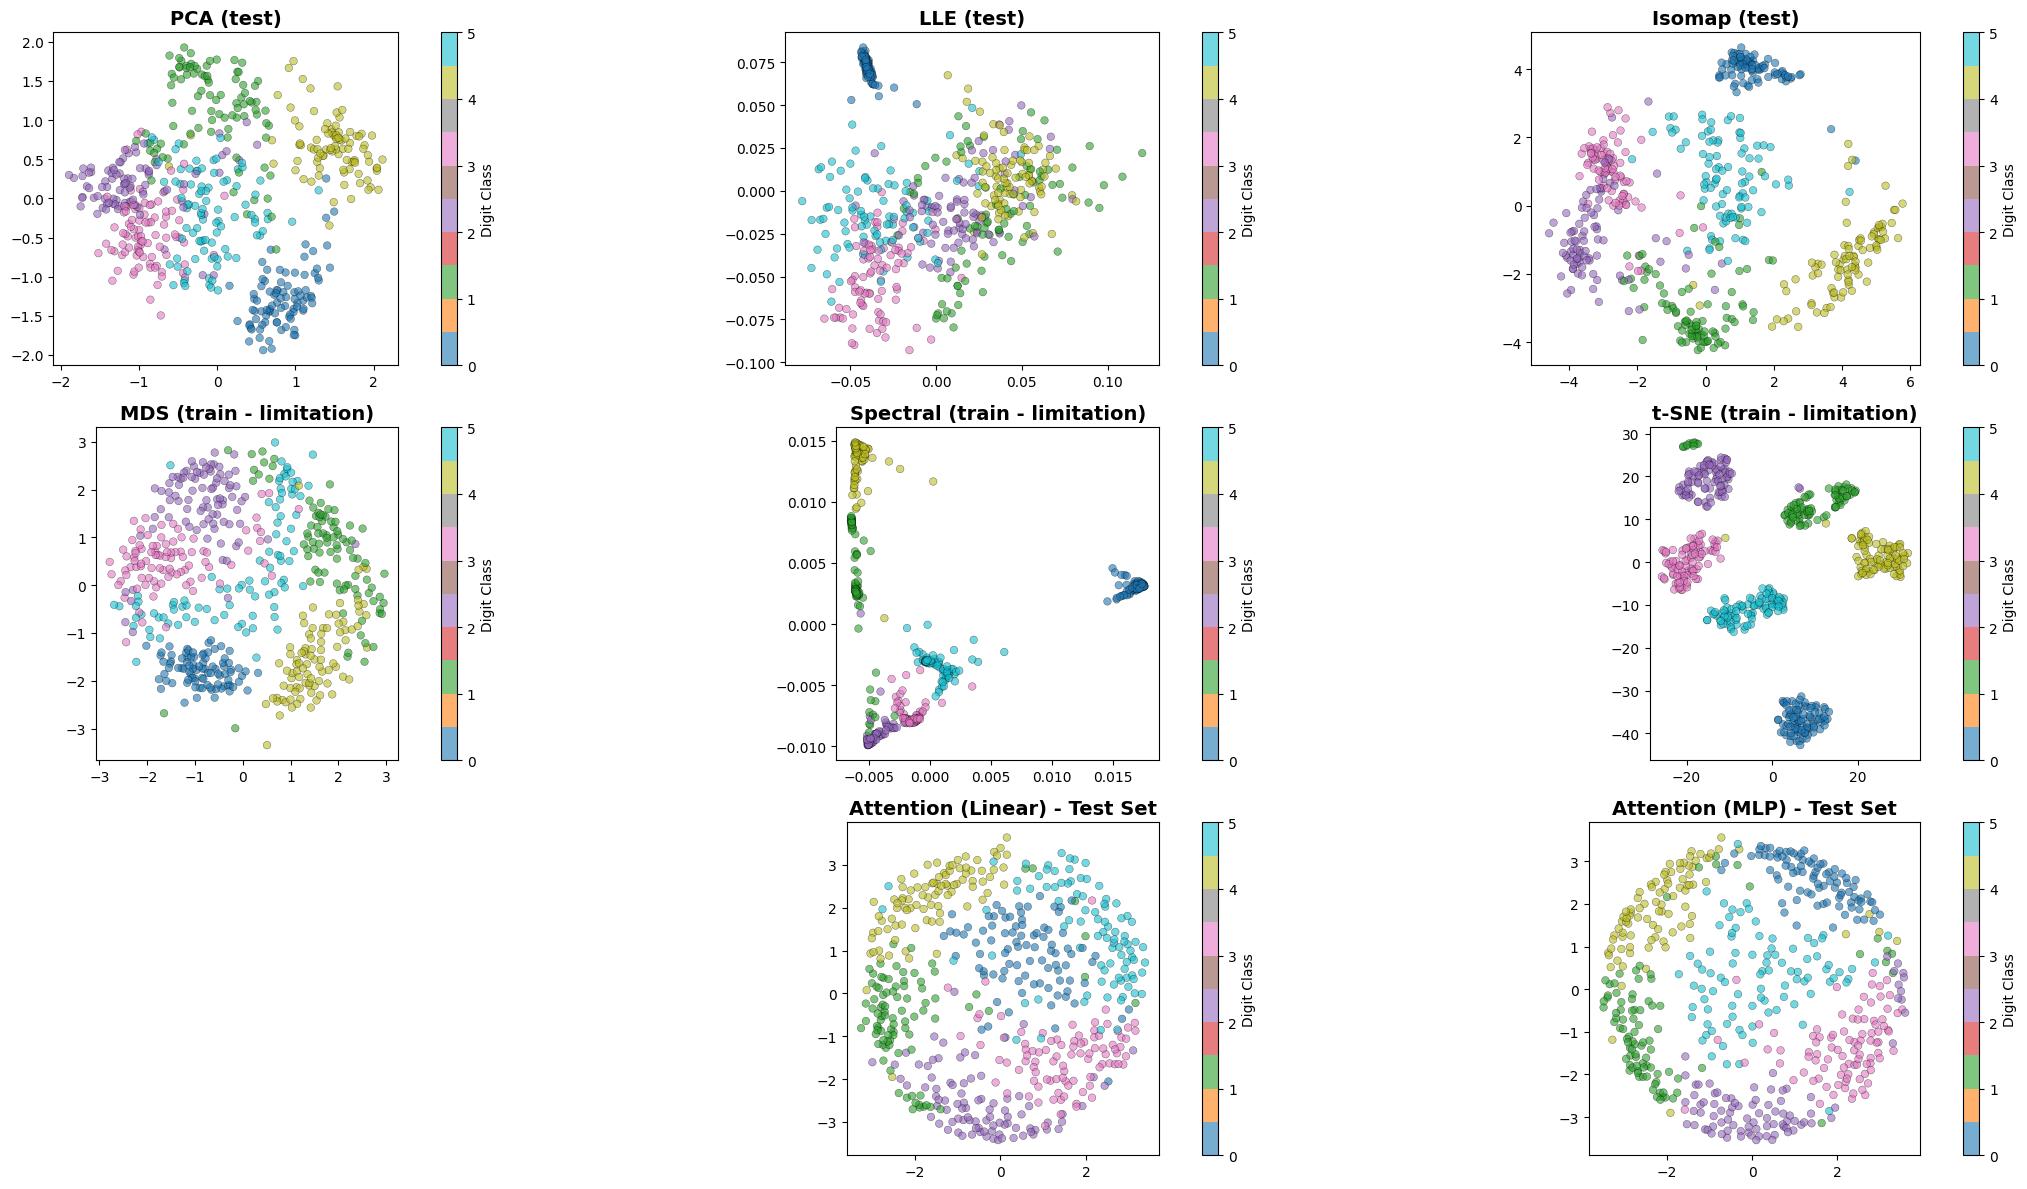

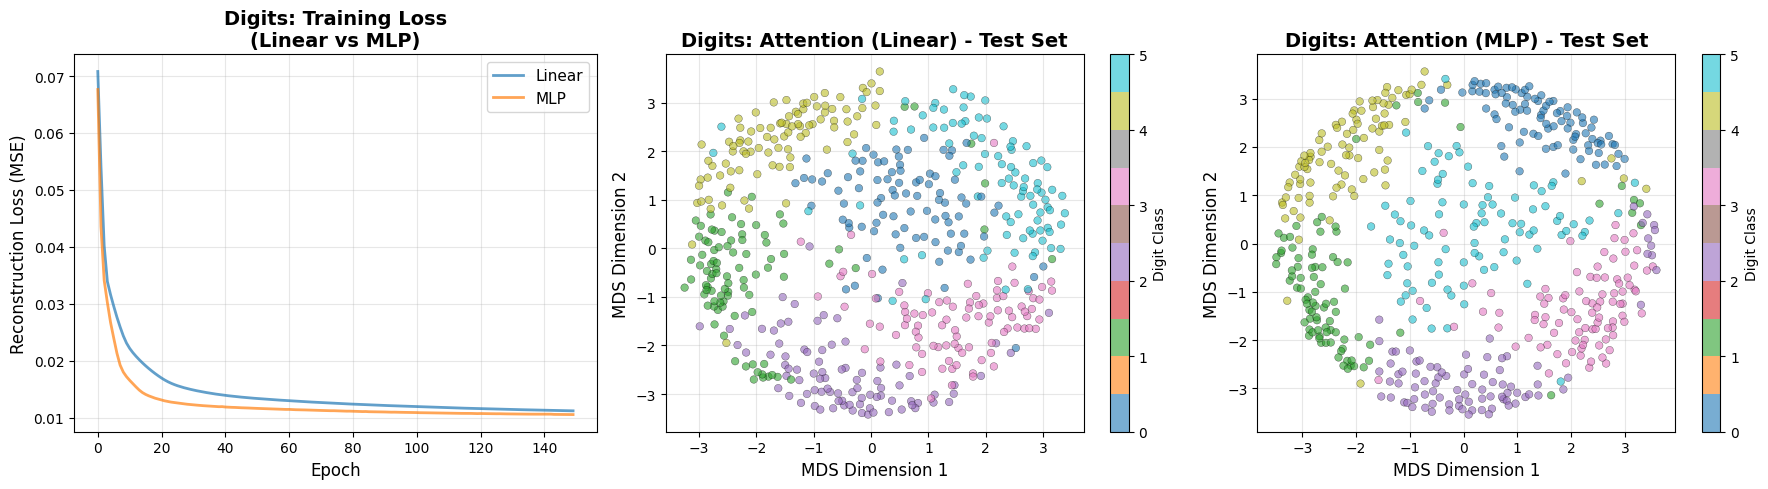

In [70]:
# Visualize digits embeddings (with attention on separate subplots)
# Methods that use test set: PCA, LLE, Isomap, Attention (Linear), Attention (MLP)
# Methods that use train set: MDS, Spectral, t-SNE (limitation - no transform method)
fig = plt.figure(figsize=(24, 12))

# Plot sklearn methods - use appropriate label array based on train/test
digits_sklearn_methods = ['PCA', 'LLE', 'Isomap', 'MDS', 'Spectral', 't-SNE']
digits_train_set_methods = ['MDS', 'Spectral', 't-SNE']  # These use train embeddings

for idx, method_name in enumerate(digits_sklearn_methods, start=1):
    if method_name in digits_methods:
        ax = fig.add_subplot(3, 3, idx)
        # Use train labels for methods that use train embeddings, test labels otherwise
        label_array = digits_labels_train if method_name in digits_train_set_methods else digits_labels_test
        scatter = ax.scatter(
            digits_methods[method_name][:, 0], 
            digits_methods[method_name][:, 1], 
            c=label_array, s=30, alpha=0.6, cmap=plt.cm.tab10, edgecolors='black', linewidths=0.3
        )
        title_suffix = " (train - limitation)" if method_name in digits_train_set_methods else " (test)"
        ax.set_title(f"{method_name}{title_suffix}", size=14, fontweight='bold')
        ax.set_aspect('equal')
        plt.colorbar(scatter, ax=ax, label='Digit Class')

# Plot attention methods on separate subplots (both use test set)
ax = fig.add_subplot(3, 3, 8)
scatter = ax.scatter(
    digits_methods['Attention (Linear)'][:, 0], 
    digits_methods['Attention (Linear)'][:, 1], 
    c=digits_labels_test, s=30, alpha=0.6, cmap=plt.cm.tab10, edgecolors='black', linewidths=0.3
)
ax.set_title('Attention (Linear) - Test Set', size=14, fontweight='bold')
ax.set_aspect('equal')
plt.colorbar(scatter, ax=ax, label='Digit Class')

ax = fig.add_subplot(3, 3, 9)
scatter = ax.scatter(
    digits_methods['Attention (MLP)'][:, 0], 
    digits_methods['Attention (MLP)'][:, 1], 
    c=digits_labels_test, s=30, alpha=0.6, cmap=plt.cm.tab10, edgecolors='black', linewidths=0.3
)
ax.set_title('Attention (MLP) - Test Set', size=14, fontweight='bold')
ax.set_aspect('equal')
plt.colorbar(scatter, ax=ax, label='Digit Class')

plt.tight_layout()
plt.show()

# Plot training curves and embeddings in the same figure (3 columns)
plt.figure(figsize=(18, 5))

# Left panel: Training curves
plt.subplot(1, 3, 1)
plt.plot(digits_history_linear['losses'], label='Linear', alpha=0.7, linewidth=2)
plt.plot(digits_history_mlp['losses'], label='MLP', alpha=0.7, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Reconstruction Loss (MSE)', fontsize=12)
plt.title('Digits: Training Loss\n(Linear vs MLP)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Middle panel: Attention (Linear) embedding - TEST set
plt.subplot(1, 3, 2)
scatter1 = plt.scatter(
    digits_embedding_linear[:, 0], digits_embedding_linear[:, 1], 
    c=digits_labels_test, s=30, alpha=0.6, cmap=plt.cm.tab10, edgecolors='black', linewidths=0.3
)
plt.xlabel('MDS Dimension 1', fontsize=12)
plt.ylabel('MDS Dimension 2', fontsize=12)
plt.title('Digits: Attention (Linear) - Test Set', fontsize=14, fontweight='bold')
plt.colorbar(scatter1, label='Digit Class')
plt.grid(True, alpha=0.3)

# Right panel: Attention (MLP) embedding - TEST set
plt.subplot(1, 3, 3)
scatter2 = plt.scatter(
    digits_embedding_mlp[:, 0], digits_embedding_mlp[:, 1], 
    c=digits_labels_test, s=30, alpha=0.6, cmap=plt.cm.tab10, edgecolors='black', linewidths=0.3
)
plt.xlabel('MDS Dimension 1', fontsize=12)
plt.ylabel('MDS Dimension 2', fontsize=12)
plt.title('Digits: Attention (MLP) - Test Set', fontsize=14, fontweight='bold')
plt.colorbar(scatter2, label='Digit Class')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Analysis: Are Results Too Good to Be True?

Let's verify that our attention-based method is actually learning meaningful structure by:
1. Checking reconstruction quality
2. Comparing attention matrices between linear and MLP
3. Analyzing whether the embeddings preserve class structure


In [71]:
# Verify reconstruction quality and attention patterns
print("="*80)
print("Verification Analysis")
print("="*80)

# Check reconstruction error on test data
def check_reconstruction_quality(model, X, device, name):
    """Check how well the model reconstructs the input."""
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(0).to(device)
    
    with torch.no_grad():
        out = model(X_tensor)
        recon = out['output'].cpu().numpy()[0]
        mse = np.mean((X - recon) ** 2)
        mae = np.mean(np.abs(X - recon))
    
    print(f"\n{name} Reconstruction Quality:")
    print(f"  MSE: {mse:.6f}")
    print(f"  MAE: {mae:.6f}")
    print(f"  Relative Error: {mae / (np.abs(X).mean() + 1e-9):.4%}")
    return mse, mae

# Check for S-curve (TEST set)
print("\n--- S-Curve Dataset (Test Set) ---")
mse_linear, mae_linear = check_reconstruction_quality(model_linear, S_points_test, device, "Linear")
mse_mlp, mae_mlp = check_reconstruction_quality(model_mlp, S_points_test, device, "MLP")

# Check for digits (TEST set)
print("\n--- Digits Dataset (Test Set) ---")
mse_digits_linear, mae_digits_linear = check_reconstruction_quality(
    digits_model_linear, digits_points_test, device, "Linear"
)
mse_digits_mlp, mae_digits_mlp = check_reconstruction_quality(
    digits_model_mlp, digits_points_test, device, "MLP"
)

# Check if embeddings preserve class structure (for digits - TEST set)
from sklearn.metrics import silhouette_score

print("\n--- Class Separation Analysis (Digits - Test Set) ---")
for method_name, embedding in digits_methods.items():
    # Handle methods that use train set (MDS, SpectralEmbedding, and t-SNE don't have transform)
    if method_name in ['t-SNE', 'MDS', 'Spectral']:
        # Use train labels for these methods since they're trained on train
        if embedding.shape[0] == len(digits_labels_train):
            sil_score = silhouette_score(embedding, digits_labels_train)
            print(f"{method_name:20s}: Silhouette Score = {sil_score:.4f} (train set - {method_name} limitation)")
    else:
        # All other methods use test set
        if embedding.shape[0] == len(digits_labels_test):
            sil_score = silhouette_score(embedding, digits_labels_test)
            print(f"{method_name:20s}: Silhouette Score = {sil_score:.4f}")


Verification Analysis

--- S-Curve Dataset (Test Set) ---

Linear Reconstruction Quality:
  MSE: 0.102082
  MAE: 0.226638
  Relative Error: 23.6774%

MLP Reconstruction Quality:
  MSE: 0.014752
  MAE: 0.100919
  Relative Error: 10.5432%

--- Digits Dataset (Test Set) ---

Linear Reconstruction Quality:
  MSE: 0.018314
  MAE: 0.076667
  Relative Error: 24.9744%

MLP Reconstruction Quality:
  MSE: 0.024983
  MAE: 0.086289
  Relative Error: 28.1089%

--- Class Separation Analysis (Digits - Test Set) ---
PCA                 : Silhouette Score = 0.3283
LLE                 : Silhouette Score = 0.2173
Isomap              : Silhouette Score = 0.4527
MDS                 : Silhouette Score = 0.2779 (train set - MDS limitation)
Spectral            : Silhouette Score = 0.6393 (train set - Spectral limitation)
t-SNE               : Silhouette Score = 0.6275 (train set - t-SNE limitation)
Attention (Linear)  : Silhouette Score = 0.2628
Attention (MLP)     : Silhouette Score = 0.3258
